# Here is the code for end-end ML framework for Linear models using scikit-learn

## Created for B EE 520
### Created by Madhava Vemuri

In [24]:
import pandas as pd  #Used to handling the datasets


## Dividing the dataset for train, test and validation

### The path to the dataset is mentioned in the "dataset_file_path", which is read using an inbuilt method in the pandas package and stored inside the variable dataframe.

In [25]:
# read the dataset using pandas dataframe using read_xlsx function 
dataset_file_path = r'portland_housing.xlsx'
dataframe =  pd.read_excel(dataset_file_path)

In [26]:
# Looking into the dataset 
print(f"The breakdown of dataset rows:{len(dataframe)} and cols:{len(dataframe.columns)}")

# There is another way to look into the dataset using the shape method
print(f"Another of looking into the dataset rows:{dataframe.shape[0]}  and cols:{dataframe.shape[1]}")

The breakdown of dataset rows:25731 and cols:348
Another of looking into the dataset rows:25731  and cols:348


In [27]:
# Here are the first 5 entries of the dataset
dataframe.head(5)

,abbreviatedAddress,address/city,address/zipcode,bathrooms,bedrooms,brokerageName,dateSold,daysOnZillow,description,favoriteCount,...,taxHistory/0/taxPaid,taxHistory/0/time,taxHistory/0/value,taxHistory/0/valueIncreaseRate,url,yearBuilt,zestimate,zestimateHighPercent,zestimateLowPercent,zpid
0,2860 NE Blossom Hill Rd,Fairview,97024,3.0,3.0,NaN,1621560000000,25.0,"2860 NE Blossom Hill Rd, Fairview, OR 97024 is...",NaN,...,2989.74,1.592260e+12,172290.0,0.029950,https://www.zillow.com/homedetails/2860-NE-Blo...,2007.0,317406.0,5.0,5.0,72258538
1,20386 NE Mackenzie Ln,Fairview,97024,3.0,3.0,Harcourts Real Estate Network Group,1619140000000,53.0,Cute as a button 3bed/2.5bath home with brand ...,NaN,...,NaN,NaN,NaN,NaN,https://www.zillow.com/homedetails/20386-NE-Ma...,2001.0,NaN,NaN,NaN,2073593774
2,1121 SW 10th Dr,Gresham,97080,3.0,4.0,ERA Freeman & Associates,1622760000000,11.0,What a wonderful large home at end of quiet cu...,NaN,...,5178.62,1.592260e+12,282340.0,0.029987,https://www.zillow.com/homedetails/1121-SW-10t...,1982.0,512355.0,5.0,5.0,53959026
3,19309 NE Glisan St,Portland,97230,1.0,3.0,"Premiere Property Group, LLC",1622760000000,11.0,NaN,1.0,...,2420.36,1.497560e+12,142330.0,0.029959,https://www.zillow.com/homedetails/19309-NE-Gl...,1953.0,NaN,NaN,NaN,176563865
4,25-65 NW 20th St,Gresham,97030,3.0,6.0,NaN,1622510000000,14.0,"25-65 NW 20th St, Gresham, OR 97030 is a apart...",NaN,...,2809.61,1.592260e+12,153180.0,0.029989,https://www.zillow.com/homedetails/25-65-NW-20...,1967.0,NaN,NaN,NaN,53819568


In [29]:
# Here are all the features in the dataset
for i in dataframe.columns : print(i)

abbreviatedAddress
address/city
address/zipcode
bathrooms
bedrooms
brokerageName
dateSold
daysOnZillow
description
favoriteCount
homeStatus
homeType
lastSoldPrice
latitude
livingArea
longitude
lotSize
pageViewCount
postingContact/name
price
priceHistory/0/attributeSource/infoString1
priceHistory/0/attributeSource/infoString2
priceHistory/0/attributeSource/infoString3
priceHistory/0/buyerAgent/name
priceHistory/0/buyerAgent/photo/url
priceHistory/0/buyerAgent/profileUrl
priceHistory/0/date
priceHistory/0/event
priceHistory/0/postingIsRental
priceHistory/0/price
priceHistory/0/priceChangeRate
priceHistory/0/pricePerSquareFoot
priceHistory/0/sellerAgent/name
priceHistory/0/sellerAgent/photo/url
priceHistory/0/sellerAgent/profileUrl
priceHistory/0/showCountyLink
priceHistory/0/source
priceHistory/0/time
priceHistory/1/attributeSource/infoString1
priceHistory/1/attributeSource/infoString2
priceHistory/1/attributeSource/infoString3
priceHistory/1/date
priceHistory/1/event
priceHistory/1/post

## We are going to focus on only 1 feature which is the Area of the house and compare that the price of the homes
feature : "livingArea" \
predict : "price"

In [123]:
# Extract the feature and the price from the dataframe into a new dataframe df

df = dataframe[['livingArea', 'price']]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25731 entries, 0 to 25730
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   livingArea  25266 non-null  float64
 1   price       25731 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 402.2 KB


### **Cleaning the dataset**: In the new dataframe 'df' if you look at the count there are some null entires where data is not present.If you carefully observe the dataframe info the non-null entries dont match indicating missing entries. We can remove these entries from the dataframe, so ensure corruption free dataset. You can use the drop_na() method from pandas to delete the entries from the dataset.

In [124]:
# Delete the non_zero entries from the dataset 
df = df.dropna()

# Check the if this has removed the entries. Now the entries would match for both columns
df.info()

<class 'pandas.DataFrame'>
Index: 25266 entries, 0 to 25730
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   livingArea  25266 non-null  float64
 1   price       25266 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 592.2 KB


In [168]:
# Convert the dataset into numpy array
X = df['livingArea'].to_numpy()
y = df['price'].to_numpy()

### Lets Visualize the entire dataset to understand the distribution. We are going to use the plot method using the pyplot package from matplotlib. The ticker method is used to add more visualization to improve the readability

In [146]:
# import the pyplot and ticker method from the matplotlib package

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Setup the default font sizes within this plt
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Text(0.5, 1.0, 'Price vs Area of Entire dataset')

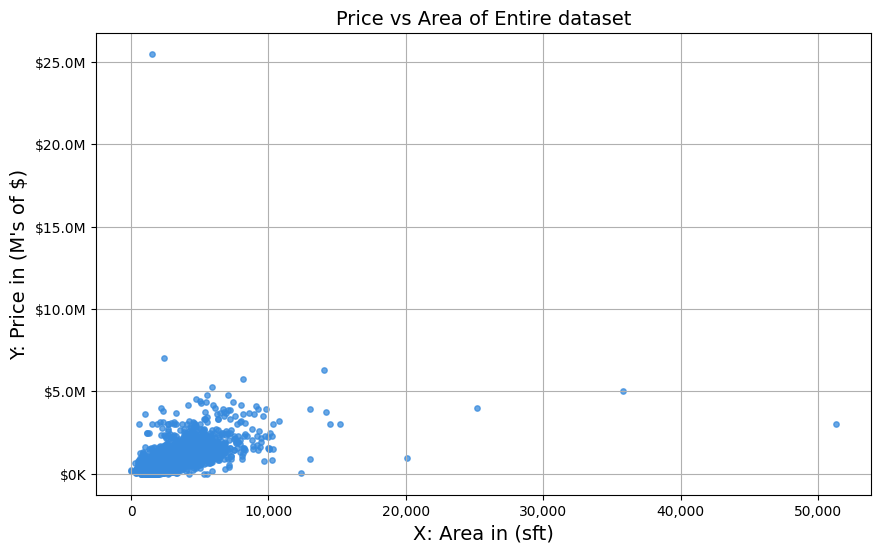

In [157]:
# Visualizing the entire dataset
 
# Defining the figuresize 
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['livingArea'],  df['price'],s=15,alpha=0.75,color='#378ADD')
ax.set_xlabel("X: Area in (sft)")
ax.set_ylabel("Y: Price in (M's of $)", rotation=90)
#plt.axis([0, 2, 0, 15])
ax.grid()

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K' if x < 1e6 else f'${x/1e6:.1f}M'))


ax.set_title("Price vs Area of Entire dataset")
#save_fig("generated_data_plot")

Text(0.5, 1.0, 'Price vs Area on a Sample of a dataset')

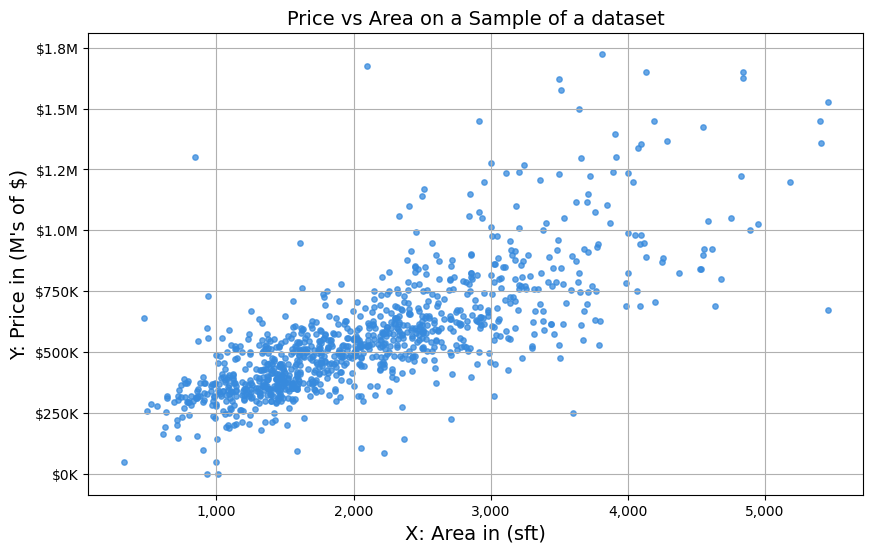

In [161]:
# lets remove some of the outliers from the dataset and sample fewer points to get the clear picture 

# First lets only focus on the dataset 
df_filtered = df[(df['price'] < df['price'].quantile(0.99)) & (df['livingArea'] < df['livingArea'].quantile(0.99))]

# First sample 1000 points  
sample = df_filtered.sample(1000)



# Defining the figuresize 
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sample['livingArea'], sample['price'],s=15,alpha=0.75,color='#378ADD')
ax.set_xlabel("X: Area in (sft)")
ax.set_ylabel("Y: Price in (M's of $)", rotation=90)
#plt.axis([0, 2, 0, 15])
ax.grid()

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K' if x < 1e6 else f'${x/1e6:.1f}M'))


ax.set_title("Price vs Area on a Sample of a dataset")
#save_fig("generated_data_plot")


## We use the test_train_split method the the scikit-learn python package to divide the entire dataset into train and test

In [45]:
# import the method from the sklearn package 
from sklearn.model_selection import train_test_split

In [227]:

# Set a value to create a random state
seed=42

# 1. Split into (Train + Val) and Test (e.g., 10% for testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.9, random_state=seed
)


In [228]:
# Lets look into the sizes of the dataset 
print(f"Entries in train X: {len(X_train)} and Y: {len(y_train)} ")
print(f"Entries in  test X: {len(X_test)} and Y: {len(y_test)} ")

Entries in train X: 22739 and Y: 22739 
Entries in  test X: 2527 and Y: 2527 


## Lets reshape the dataset to meet the shape expectation seen in training

In [229]:
#The dataset before reshaping 
print(f"The shape of train dataset shape: {X_train.shape}")

# Currently the dataset is 1D, we need to to convert this to a 2D array using reshape method. This convert the 1D array to 2D array
# Training case
X_train = X_train.reshape(-1,1)
y_train = y_train.reshape(-1,1)
# Testing case
X_test = X_test.reshape(-1,1)
y_test = y_test.reshape(-1,1)

print(f"The shape of train dataset after reshape: {X_train.shape}")

The shape of train dataset shape: (22739,)
The shape of train dataset after reshape: (22739, 1)



## Lets create a simple [Linear Regression](https://scikit-learn.org/stable/modules/linear_model.html#ordinary-least-squares) scikitlearn's linear_model

In [230]:
from sklearn.linear_model import LinearRegression

## Cost Function in Scikit-learn LinearRegression 

Scikit-learn's `LinearRegression` uses **Ordinary Least Squares (OLS)**, which minimizes the **Residual Sum of Squares (RSS)**:

$$J(\theta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

where $y_i$ is the actual value and $\hat{y}_i = \theta_0 + \theta_1 x_1 + \dots + \theta_p x_p$ is the predicted value.

## How does it Solves It

**Scikit-learn does not use gradient descent to minimize this.** It solves it directly using the **closed-form normal equation**:

$$\theta = (X^T X)^{-1} X^T y$$

This gives the exact optimal solution in one shot — no iterations, no learning rate. Under the hood it uses `scipy.linalg.lstsq` (via SVD decomposition) rather than literally inverting $X^T X$, which is numerically more stable.

## Practical Implication

`LinearRegression` has no hyperparameters like learning rate or number of epochs — it just solves directly. If you want gradient descent-based linear regression in scikit-learn, use `SGDRegressor` instead, which does use an iterative approach and exposes those parameters.

In [231]:
# Let's first create a simple Linear regression object handle using LinearREgression
lin_reg = LinearRegression()

In [232]:
# Lets train using the train dataset
lin_reg.fit(X_train, y_train)

# here is the breakdown of the array 
print(f"Slope: {lin_reg.coef_}  bias:{lin_reg.intercept_}")

Slope: [[214.39813106]]  bias:[117990.98137148]


In [ ]:
# let us try to see the performance on a test data
y_test_pred_lin = lin_reg.predict(X_test)

# import the numpy package 
import numpy as np

# Lets calculate the Mean Sum of Residual square L2^2 or MSE error norm on the test data using numpy
Cost_on_test = np.sum(np.square(np.subtract(y_test_pred_lin, y_test)))

print(f"The cost on the test dataset using Sum of Squares values {Cost_on_test} and its average (MSE Error) {Cost_on_test/len(y_test_pred)}")

# Lets calculate the Mean absolute error L1 norm or MAE error norm on the test data using numpy
Cost_on_test = np.sum(np.absolute(np.subtract(y_test_pred_lin, y_test)))

print(f"The cost on the test dataset using Sum of Absolute values {Cost_on_test} and its average (MAE Error) {Cost_on_test/len(y_test_pred)}")

The cost on the test dataset using Sum of Squares values 103381972424080.38 and its average (MSE Error) 40910950702.05001
The cost on the test dataset using Sum of Absolute values 298860950.33316445 and its average (MAE Error) 118267.09550184585


### Lets plot the prediction on the test and compare it with the expected values 

Text(0.5, 1.0, 'Expected vs Predicted on the test dataset')

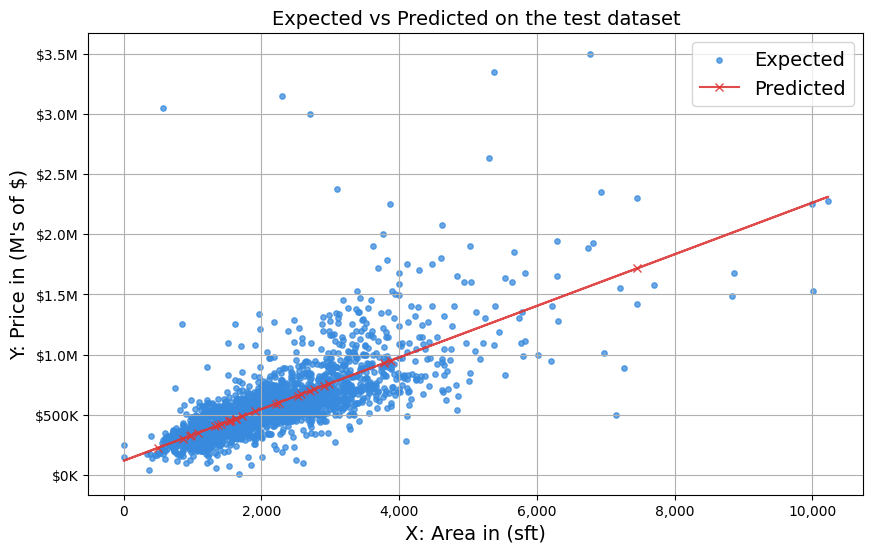

In [391]:
# Defining the figuresize 
fig, ax = plt.subplots(figsize=(10, 6))
#plot the expected values 
ax.scatter(X_test, y_test,s=15,alpha=0.75,color='#378ADD',label='Expected')
#plot the expected values 
ax.plot(X_test, y_test_pred_lin,alpha=0.9,color="#DD3737",marker='x', markevery=100,label='Predicted')
ax.set_xlabel("X: Area in (sft)")
ax.set_ylabel("Y: Price in (M's of $)", rotation=90)
ax.grid()

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K' if x < 1e6 else f'${x/1e6:.1f}M'))

ax.legend()
ax.set_title("Expected vs Predicted on the test dataset")
#save_fig("generated_data_plot")

### Lets work on implementing the Stochastic gradient descent algorithm. There are 2 approaches implementing this algorithm,

1) Use the [SGDRegresor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#sklearn.linear_model.SGDRegressor) from the scikit-learn library. 
2) Write the algorithm form scratch -- This method will be useful to understand the internal working of the training algorithm 

In [235]:
# Using the first method. Lets use the method SGDRegressor from the sklean library 

from sklearn.linear_model import SGDRegressor

### Lets define some of the hyperparameters used in the training procedure

1) epochs: This sets the # of iterations the algorithm will run the training 
2) alpha: Learning rate parameter This decides the step size as you keep iterating 
3) lamda: Regularizaiton parameter to control overfitting    
4) tol:   Stopping Criterion used to halt the training to prevent overfitting
5) patience: This patience used to train the model for a certain time to see if there is a change in the training performance

In [381]:
# defining the above parameter here
epochs = 1000_000   # the max number of iterations
alpha = 0.001   # the starting learning rate to be used in the design 
lamda =0      # The regularizatoin term
tol = 1e-3      # The stopping criterion
patience = 500  # The patience is used to wait until for a certain epochs before stopping

### Lets use the SGDRegressor to train the model  using fit() method

In [ ]:
sgd_reg = SGDRegressor(loss='squared',max_iter=epochs, tol=tol, penalty='l2', eta0=alpha,  random_state=42, alpha= lamda, # currently setting penalty = None to remove any regularization term from the model training
                       early_stopping=True,n_iter_no_change=patience, validation_fraction=0.1)   # use 10% of training data for validation
sgd_reg.fit(X_train,y_train.ravel())  # y.ravel() because fit() expects 1D targets

# Check for how many spochs did the model run 
print(f"The model is set to run for {sgd_reg.max_iter} and early stopping was triggered at {sgd_reg.n_iter_}")

The model is set to run for 1000000 and early stopping was triggered at 501


### Lets look into the performance of the SGD on the test data and our previous result

We are going to use the [mean_square_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) and [mean_absolute_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html) from the sklearn package to give the mean square error and mean absolute error

In [383]:
# import the metric 
from sklearn.metrics import mean_squared_error  # MSE loss
from sklearn.metrics import mean_absolute_error # MAE_loss 

In [389]:
# let us try to see the performance on a test data
y_test_pred_sgd = sgd_reg.predict(X_test)

# Lets calculate the Mean Sum of Residual square L2^2 or MSE error norm on the test data using sklearn.metrics
MSE_loss_sgd = mean_squared_error(y_true=y_test, y_pred=y_test_pred_sgd)
MAE_loss_sgd = mean_absolute_error(y_true=y_test, y_pred=y_test_pred_sgd)


# Lets calculate the Mean Sum of Residual square L2^2 or MSE error norm on the test data using sklearn.metrics
MSE_loss_lin = mean_squared_error(y_true=y_test, y_pred=y_test_pred_lin)
MAE_loss_lin = mean_absolute_error(y_true=y_test, y_pred=y_test_pred_lin)

print(f"For SGD: Mean Square Loss {MSE_loss_sgd}, The Mean Absolute Loss {MAE_loss_sgd}")
print(f"For LinReg: Mean Square Loss {MSE_loss_lin}, The Mean Absolute Loss {MAE_loss_lin}")

For SGD: Mean Square Loss 43510736585.94219, The Mean Absolute Loss 124938.53420989333
For LinReg: Mean Square Loss 40910950702.05001, The Mean Absolute Loss 118267.09550184585


Text(0.5, 1.0, 'Expected vs Predicted on the test dataset')

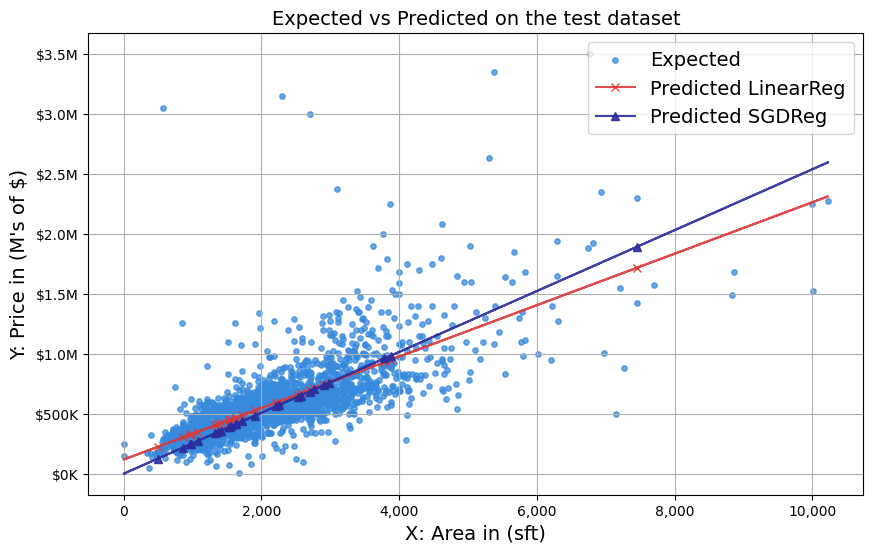

In [390]:

# Defining the figuresize 
fig, ax = plt.subplots(figsize=(10, 6))
#plot the expected values 
ax.scatter(X_test, y_test,s=15,alpha=0.75,color='#378ADD',label='Expected')
#plot the expected values 
ax.plot(X_test, y_test_pred_lin,alpha=0.9,color="#DD3737",marker='x', markevery=100,label='Predicted LinearReg')
ax.plot(X_test, y_test_pred_sgd,alpha=0.9,color="#2B2B9D",marker='^', markevery=100,label='Predicted SGDReg')
ax.set_xlabel("X: Area in (sft)")
ax.set_ylabel("Y: Price in (M's of $)", rotation=90)
ax.grid()

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K' if x < 1e6 else f'${x/1e6:.1f}M'))

ax.legend()
ax.set_title("Expected vs Predicted on the test dataset")
#save_fig("generated_data_plot")

### Lets first normalize the dataset using the [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) from sklearn library to apply normalization to the dataset to see if this improves the performance.


In [392]:
from sklearn.preprocessing import StandardScaler

# fit scaler only on training data
scaler_X = StandardScaler()


X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)